# Capítulo 2 — Radiação Solar e Infravermelha: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | curvas de Planck Sol × Terra; Wien e Stefan–Boltzmann | NumPy |
| 2 | geometria solar: elevação, duração do dia, **mapa de insolação** | NumPy |
| 3 | lei de Beer como EDO: atenuação do feixe solar | `scipy.solve_ivp` |
| 4 | efeito estufa: $N$ camadas × coluna cinza | `climlab` |

Exercícios numéricos N1–N4 no fim; soluções em `cap02_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

# constantes do Cap. 2 (Stull)
c1  = 3.74e8      # W m-2 um4  — 1ª constante de Planck (forma do livro)
c2  = 1.44e4      # um K       — 2ª constante de Planck
a_W = 2897.0      # um K       — constante de Wien
sigma = 5.67e-8   # W m-2 K-4  — Stefan-Boltzmann
S0  = 1361.0      # W m-2      — constante solar
T_sol, T_terra = 5772.0, 288.0

## Caso 1 — Quem emite o quê: Planck, Wien e Stefan–Boltzmann

$$E^*_\lambda = \frac{c_1}{\lambda^5\left[e^{c_2/(\lambda T)}-1\right]},\qquad
\lambda_{max} = \frac{2897\ \mu\mathrm{m\,K}}{T},\qquad E^* = \sigma T^4$$

Sol e Terra lado a lado, em escala log–log — repare como as duas bandas quase não se tocam.

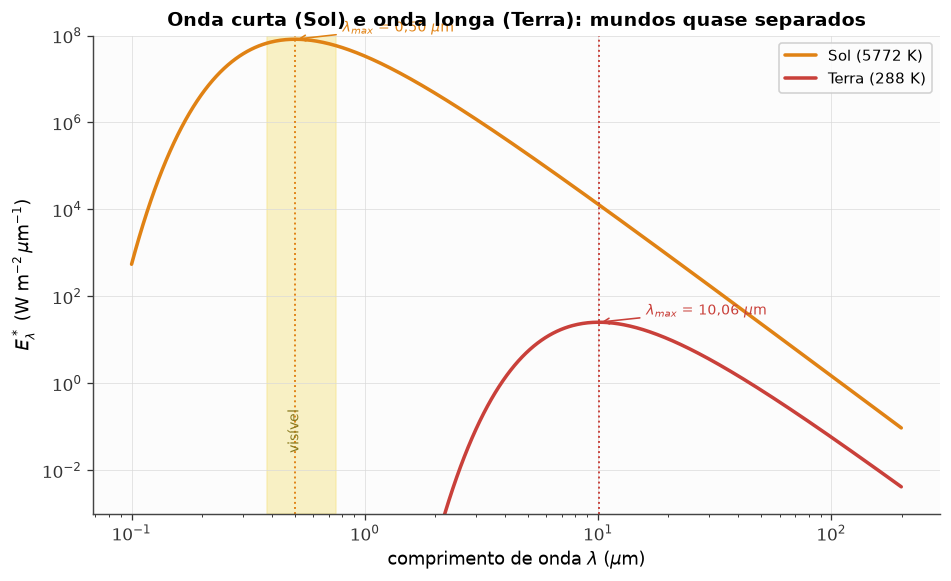

T =   5772 K:  ∫Planck = 6.270e+07 W/m²  |  σT⁴ = 6.293e+07 W/m²  (razão 0.9962)
T =    288 K:  ∫Planck = 3.883e+02 W/m²  |  σT⁴ = 3.901e+02 W/m²  (razão 0.9955)


In [2]:
def planck(lam_um, T):
    """Emitância espectral de corpo negro (W m-2 um-1), lambda em micrômetros."""
    with np.errstate(over='ignore'):          # exp estoura p/ λT pequeno → E ≈ 0, ok
        return c1/(lam_um**5*(np.exp(c2/(lam_um*T)) - 1))

lam = np.logspace(-1, 2.3, 600)   # 0,1 a 200 um

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.loglog(lam, planck(lam, T_sol), color=CORES['laranja'], label=f'Sol ({T_sol:.0f} K)')
ax.loglog(lam, planck(lam, T_terra), color=CORES['vermelho'],
          label=f'Terra ({T_terra:.0f} K)')
ax.axvspan(0.38, 0.75, color='#f6e58d', alpha=0.5)
ax.text(0.5, 3e-2, 'visível', rotation=90, fontsize=9, ha='center', color='#8a7a1e')
for T, cor in [(T_sol, CORES['laranja']), (T_terra, CORES['vermelho'])]:
    lmax = a_W/T
    ax.axvline(lmax, color=cor, ls=':', lw=1.2)
    ax.annotate(f'$\\lambda_{{max}}$ = {lmax:.2f} $\\mu$m'.replace('.', ','),
                xy=(lmax, planck(lmax, T)), xytext=(lmax*1.6, planck(lmax, T)*1.5),
                fontsize=9, color=cor, arrowprops=dict(arrowstyle='->', color=cor))
ax.set(xlabel='comprimento de onda $\\lambda$ ($\\mu$m)',
       ylabel='$E^*_\\lambda$ (W m$^{-2}\\,\\mu$m$^{-1}$)',
       title='Onda curta (Sol) e onda longa (Terra): mundos quase separados',
       ylim=(1e-3, 1e8))
ax.legend(loc='upper right')
plt.show()

# Stefan–Boltzmann numérico: integral da curva de Planck
for T in [T_sol, T_terra]:
    E_num = np.trapezoid(planck(lam, T), lam)
    print(f'T = {T:6.0f} K:  ∫Planck = {E_num:.3e} W/m²  |  σT⁴ = {sigma*T**4:.3e} W/m²'
          f'  (razão {E_num/(sigma*T**4):.4f})')

## Caso 2 — Geometria solar: de São Paulo ao mapa global de insolação

$$\delta_s = \Phi_r\cos\!\left[\frac{2\pi(d-d_r)}{d_y}\right],\qquad
\cos H_0 = -\tan\phi\,\tan\delta_s$$

Insolação média diária no topo da atmosfera:
$$\bar Q = \frac{S_0}{\pi}\left(H_0\sin\phi\sin\delta_s + \cos\phi\cos\delta_s\sin H_0\right)$$

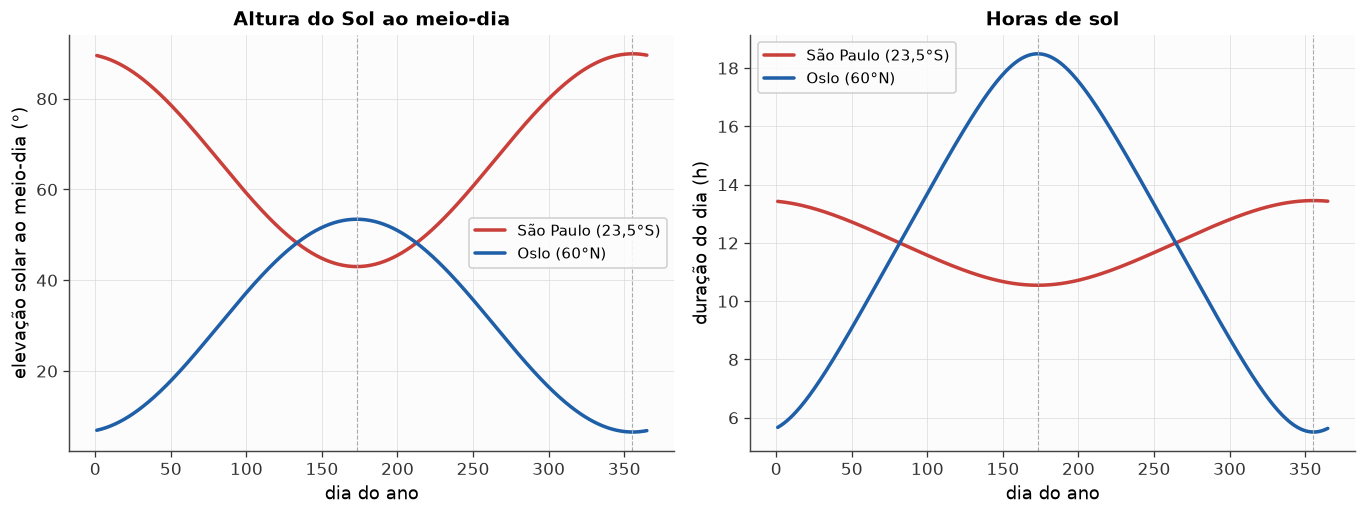

In [3]:
Phi_r, d_r, d_y = np.deg2rad(23.44), 173, 365.25

def declinacao(d):
    return Phi_r*np.cos(2*np.pi*(d - d_r)/d_y)

def H0(phi, delta):
    """Ângulo horário do pôr do sol (rad), com casos polares."""
    x = -np.tan(phi)*np.tan(delta)
    return np.arccos(np.clip(x, -1, 1))

def insolacao_diaria(phi, d):
    dl = declinacao(d)
    h0 = H0(phi, dl)
    return S0/np.pi*(h0*np.sin(phi)*np.sin(dl) + np.cos(phi)*np.cos(dl)*np.sin(h0))

dias = np.arange(1, 366)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for nome, phi_g, cor in [('São Paulo (23,5°S)', -23.55, CORES['vermelho']),
                          ('Oslo (60°N)', 60.0, CORES['azul'])]:
    phi = np.deg2rad(phi_g)
    elev_meiodia = 90 - np.abs(phi_g - np.rad2deg(declinacao(dias)))
    dur = 24/np.pi*H0(phi, declinacao(dias))
    ax1.plot(dias, elev_meiodia, color=cor, label=nome)
    ax2.plot(dias, dur, color=cor, label=nome)
ax1.set(xlabel='dia do ano', ylabel='elevação solar ao meio-dia (°)',
        title='Altura do Sol ao meio-dia')
ax2.set(xlabel='dia do ano', ylabel='duração do dia (h)',
        title='Horas de sol')
ax1.legend(); ax2.legend()
for ax in (ax1, ax2):
    for d_st, nome in [(173, 'solst. jun'), (355, 'solst. dez')]:
        ax.axvline(d_st, color='#aaaaaa', lw=0.7, ls='--')
fig.tight_layout(); plt.show()

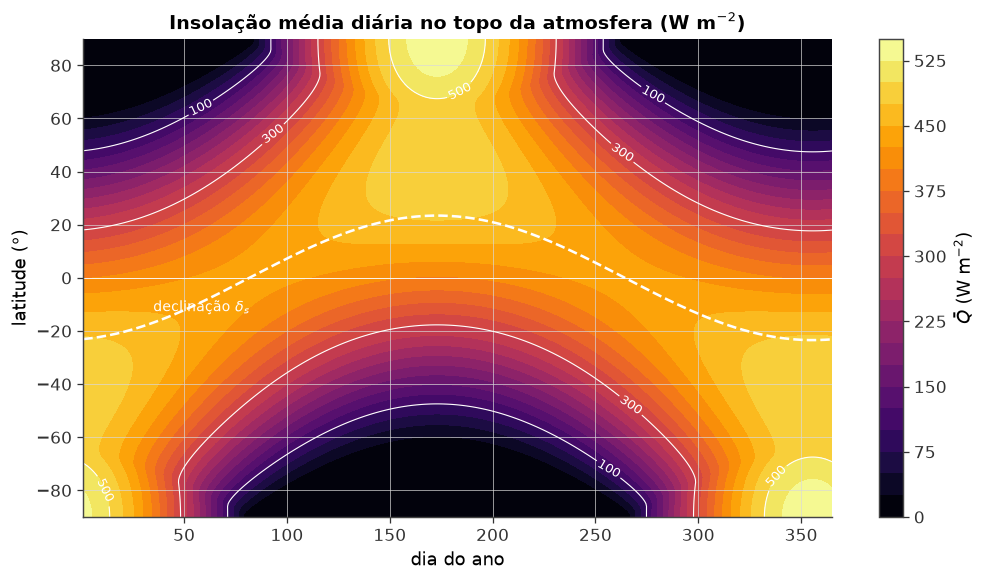

Note: no solstício de verão o POLO recebe mais energia diária que o equador
  polo sul, solst. dez: 541 W/m²
  equador, mesmo dia  : 397 W/m²


In [4]:
# o gráfico clássico: insolação média diária (lat × dia do ano)
lats = np.linspace(-90, 90, 181)
Q = np.array([[insolacao_diaria(np.deg2rad(la), d) for d in dias] for la in lats])

fig, ax = plt.subplots(figsize=(10.5, 5.4))
cf = ax.contourf(dias, lats, Q, levels=21, cmap='inferno')
cs = ax.contour(dias, lats, Q, levels=[100, 300, 500], colors='white',
                linewidths=0.7)
ax.clabel(cs, fmt='%.0f', fontsize=8)
ax.plot(dias, np.rad2deg(declinacao(dias)), color='white', ls='--', lw=1.6)
ax.text(35, np.rad2deg(declinacao(35))+4, 'declinação $\\delta_s$',
        color='white', fontsize=9)
ax.axhline(0, color='white', lw=0.5)
ax.set(xlabel='dia do ano', ylabel='latitude (°)',
       title='Insolação média diária no topo da atmosfera (W m$^{-2}$)')
fig.colorbar(cf, label='$\\bar{Q}$ (W m$^{-2}$)')
plt.show()

print('Note: no solstício de verão o POLO recebe mais energia diária que o equador')
print(f'  polo sul, solst. dez: {insolacao_diaria(np.deg2rad(-90), 355):.0f} W/m²')
print(f'  equador, mesmo dia  : {insolacao_diaria(0.0, 355):.0f} W/m²')

## Caso 3 — Lei de Beer como EDO: o caminho do feixe solar

$$\frac{dE}{ds} = -k\,\rho(z)\,E,\qquad \rho(z)=\rho_0 e^{-z/H_\rho}$$

O feixe desce inclinado: $ds = dz/\sin\Psi$. Integramos do topo (50 km) até o chão para vários ângulos de elevação solar — e descobrimos por que o pôr do sol é fraco.

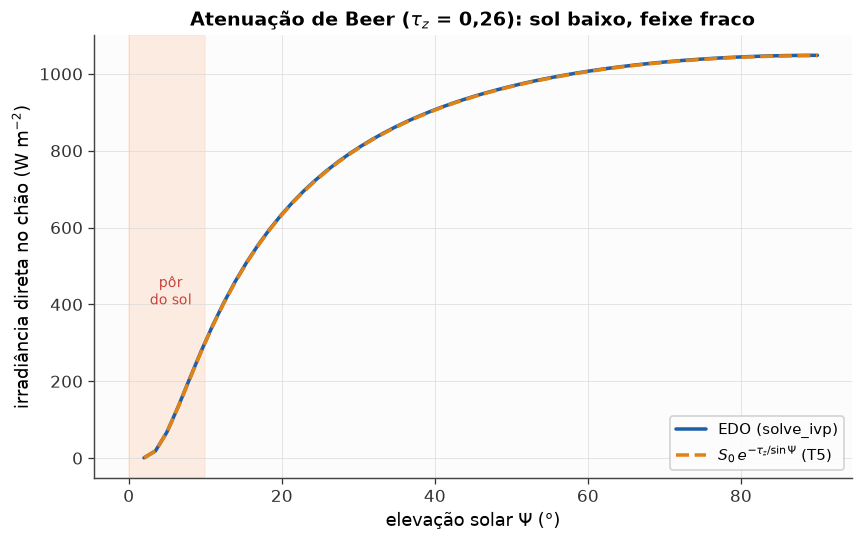

transmissividade com sol a pino: 0.77; a 5° de elevação: 0.05


In [5]:
from scipy.integrate import solve_ivp

rho0, Hrho = 1.225, 8.55e3        # kg/m3, m (Cap. 1!)
k_abs = 2.5e-5                     # m2/kg — absorção efetiva (ar limpo, banda larga)

def dEdz(z, E, sinPsi):
    return +k_abs*rho0*np.exp(-z/Hrho)*E/sinPsi   # integrando de cima p/ baixo

elevs = np.linspace(2, 90, 60)
E_chao = []
for pe in elevs:
    sol = solve_ivp(dEdz, [50e3, 0], [S0], args=(np.sin(np.deg2rad(pe)),),
                    rtol=1e-8)
    E_chao.append(sol.y[0, -1])
E_chao = np.array(E_chao)

# comparação com a fórmula fechada do exercício T5
tau_z = k_abs*rho0*Hrho
E_teo = S0*np.exp(-tau_z/np.sin(np.deg2rad(elevs)))

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(elevs, E_chao, color=CORES['azul'], label='EDO (solve_ivp)')
ax.plot(elevs, E_teo, '--', color=CORES['laranja'],
        label='$S_0\\,e^{-\\tau_z/\\sin\\Psi}$ (T5)')
ax.axvspan(0, 10, color='#fbe1d0', alpha=0.6)
ax.text(5.5, 400, 'pôr\ndo sol', ha='center', fontsize=9, color=CORES['vermelho'])
ax.set(xlabel='elevação solar $\\Psi$ (°)',
       ylabel='irradiância direta no chão (W m$^{-2}$)',
       title=f'Atenuação de Beer ($\\tau_z$ = {tau_z:.2f}): sol baixo, feixe fraco'.replace('.', ','))
ax.legend()
plt.show()
print(f'transmissividade com sol a pino: {E_chao[-1]/S0:.2f}; '
      f'a 5° de elevação: {np.interp(5, elevs, E_chao)/S0:.2f}')

## Caso 4 — Efeito estufa: das $N$ camadas ao modelo cinza (`climlab`)

Balanço da Terra sem atmosfera: $T_e = [(1-A)S_0/4\sigma]^{1/4} \approx 255$ K. Com $N$ camadas opacas ao IV (exercício N4): $T_s = (N+1)^{1/4}\,T_e$.

O [`climlab`](https://climlab.readthedocs.io) (Brian Rose) resolve a versão contínua — uma coluna com radiação cinza — encontrando o perfil $T(p)$ de equilíbrio.

T_e = 254.6 K = -18.6 °C  (sem atmosfera)
Integrating for 1095 steps, 1095.7266 days, or 3 years.


Total elapsed time is 2.998010635134713 years.
abs_coeff = 2.0e-4:  T_superfície = 303.9 K
Integrating for 1095 steps, 1095.7266 days, or 3 years.


Total elapsed time is 2.998010635134713 years.
abs_coeff = 4.0e-4:  T_superfície = 336.6 K


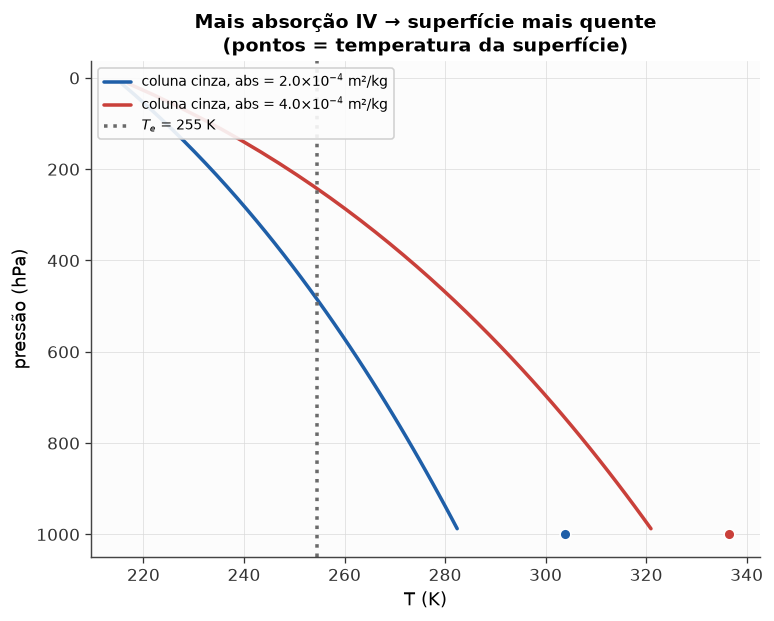

In [6]:
import warnings
warnings.filterwarnings('ignore', message='Cannot import')   # extensões Fortran opcionais ausentes
import climlab

A = 0.30
Te = ((1-A)*S0/(4*sigma))**0.25
print(f'T_e = {Te:.1f} K = {Te-273.15:.1f} °C  (sem atmosfera)')

cores_abs = [CORES['azul'], CORES['vermelho']]
fig, ax = plt.subplots(figsize=(7.5, 5.6))
for abs_c, cor in zip([2.0, 4.0], cores_abs):
    col = climlab.GreyRadiationModel(num_lev=40, abs_coeff=abs_c*1e-4)
    col.integrate_years(3)
    Ts_val = float(np.squeeze(col.Ts))
    ax.plot(np.squeeze(col.Tatm), col.lev, color=cor,
            label=f'coluna cinza, abs = {abs_c}×10$^{{-4}}$ m²/kg')
    ax.scatter([Ts_val], [1000], color=cor, zorder=5, s=45,
               edgecolor='white')
    print(f'abs_coeff = {abs_c}e-4:  T_superfície = {Ts_val:.1f} K')
ax.axvline(Te, color=CORES['cinza'], ls=':', label=f'$T_e$ = {Te:.0f} K')
ax.invert_yaxis()
ax.set(xlabel='T (K)', ylabel='pressão (hPa)',
       title='Mais absorção IV → superfície mais quente\n(pontos = temperatura da superfície)')
ax.legend(loc='upper left', fontsize=8.5)
plt.show()

**Discussão.** Dobrar o coeficiente de absorção IV aquece a superfície — o mecanismo do efeito estufa em sua forma mais nua. Note também que a estratosfera do modelo **esfria**: mais absorção embaixo significa menos IV chegando em cima. O mesmo padrão (aquece embaixo, esfria em cima) é a impressão digital do aumento de CO₂ observado na atmosfera real (Cap. 21).

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap02_solucoes.ipynb`**.

**N1** — Verifique numericamente Wien (máximo da curva de Planck) e Stefan–Boltzmann (integral) para $T = 5772$ e $288$ K.

**N2** — Elevação ao meio-dia e duração do dia ao longo do ano para São Paulo × Oslo (refine o Caso 2: acrescente a data em que cada cidade tem o dia mais curto e a insolação diária correspondente).

**N3** — Ajuste $\tau_z$ aos dados de irradiância vs. elevação solar abaixo (medidos num dia limpo) usando $E = S_0 e^{-\tau_z/\sin\Psi}$; estime a transmissividade com sol a pino.

**N4** — Estufa de $N$ camadas: trace $T_s(N) = (N+1)^{1/4}T_e$ para $N = 0\ldots8$ e ache o $N$ efetivo que reproduz os 288 K observados; compare com o Caso 4.

In [7]:
# N1 — sua solução aqui


In [8]:
# N2 — sua solução aqui


In [9]:
# N3 — sua solução aqui. Dados (elevação °, irradiância W/m²):
elev_dados = np.array([10, 15, 20, 30, 40, 50, 60, 75, 90])
E_dados    = np.array([395, 560, 668, 790, 851, 888, 910, 929, 936])


In [10]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*